# Modelo unificado SESCO — 6 recursos MVP

Procesa en lote los recursos de producción promedio diaria (petróleo y gas por provincia, cuenca y empresa) y genera un dataset unificado para el dashboard.

## 1. Configuración e imports

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

NOTEBOOK_DIR = Path.cwd()
EXPLORATION_DIR = (
    NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR / "exploration"
)
SCRIPTS_DIR = EXPLORATION_DIR / "scripts"
RAW_DIR = EXPLORATION_DIR / "data" / "raw"
PROCESSED_DIR = EXPLORATION_DIR / "data" / "processed"

sys.path.insert(0, str(SCRIPTS_DIR))
import sesco_processing as sp

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print(f"Exploration: {EXPLORATION_DIR}")


Exploration: c:\Proyectos\Dashboards\OilAndGas\exploration


## 2. Recursos MVP

In [2]:
SESCO_RESOURCES = {
    "petroleo_provincia": {
        "producto": "petroleo",
        "agrupador_tipo": "provincia",
        "nombre_recurso": "Producción de petróleo promedio diaria por provincia",
    },
    "gas_provincia": {
        "producto": "gas",
        "agrupador_tipo": "provincia",
        "nombre_recurso": "Producción de gas promedio diaria por provincia",
    },
    "petroleo_cuenca": {
        "producto": "petroleo",
        "agrupador_tipo": "cuenca",
        "nombre_recurso": "Producción de petróleo promedio diaria por cuenca",
    },
    "gas_cuenca": {
        "producto": "gas",
        "agrupador_tipo": "cuenca",
        "nombre_recurso": "Producción de gas promedio diaria por cuenca",
    },
    "petroleo_empresa": {
        "producto": "petroleo",
        "agrupador_tipo": "empresa",
        "nombre_recurso": "Producción de petróleo promedio diaria por empresa",
    },
    "gas_empresa": {
        "producto": "gas",
        "agrupador_tipo": "empresa",
        "nombre_recurso": "Producción de gas promedio diaria por empresa",
    },
}

list(SESCO_RESOURCES.keys())


['petroleo_provincia',
 'gas_provincia',
 'petroleo_cuenca',
 'gas_cuenca',
 'petroleo_empresa',
 'gas_empresa']

## 3. Consultar CKAN y listar recursos

In [3]:
package = sp.fetch_ckan_package()
df_resources = sp.list_resources(package)
print(f"Dataset: {package.get('title')}")
print(f"Recursos CKAN: {len(df_resources)}")
df_resources[["name", "format", "last_modified"]].head(10)


Dataset: Producción de Petróleo y Gas (SESCO)
Recursos CKAN: 41


,name,format,last_modified
0,Producción de Petróleo y Gas - desde 2019 - Se...,ZIP,2023-11-24T17:11:31.273629
1,Balances de Gas - desde 2009 - Sesco Web (Tabl...,ZIP,2019-03-07T15:19:37.091230
2,Producción de Petróleo y Gas - 2009 a 2018 - (...,ZIP,2023-11-24T17:03:36.936971
3,Producción de Petróleo y Gas - hasta 2008 - (...,ZIP,NaN
4,Disponibilidad de petróleo a fin de mes ant. 2009,CSV,2017-07-28T09:44:37.454531
5,Dist. de condensado y existencias a fin de mes...,CSV,2017-07-28T09:44:52.176571
6,Distribucion de gasolina y existencias a fin d...,CSV,2017-07-28T09:45:10.519549
7,Distribución de petróleo y existencias a fin d...,CSV,2017-07-28T09:45:34.620611
8,Producción de GLP Condensado y Gasolina Estabi...,CSV,2023-01-17T09:51:16.612783
9,Producción de petróleo anterior al 2009,CSV,2017-07-28T09:56:56.559201


## 4. Procesar los 6 recursos

In [4]:
results, df_sesco_model, df_validaciones = sp.process_all_resources(
    SESCO_RESOURCES,
    verbose=True,
)

df_validaciones



[petroleo_provincia] Producción de petróleo promedio diaria por provincia
  periodo <- indice_tiempo
  produccion <- produccion_petroleo_promedio_dia_m3
  agrupador <- provincia
Advertencia: se excluye 2026-01 porque parece incompleto. Representa 5.9% del período anterior.
  filas: 2,505 -> 2,498 | último válido: 2025-12

[gas_provincia] Producción de gas promedio diaria por provincia
  periodo <- indice_tiempo
  produccion <- produccion_gas_promedio_dia_mm3
  agrupador <- provincia
Advertencia: se excluye 2026-04 porque parece incompleto. Representa 0.0% del período anterior.
  filas: 2,493 -> 2,488 | último válido: 2026-03

[petroleo_cuenca] Producción de petróleo promedio diaria por cuenca
  periodo <- indice_tiempo
  produccion <- produccion_petroleo_promedio_dia_m3
  agrupador <- cuenca
  filas: 2,013 -> 2,013 | último válido: 2025-11

[gas_cuenca] Producción de gas promedio diaria por cuenca
  periodo <- indice_tiempo
  produccion <- produccion_gas_promedio_dia_mm3
  agrupador <

,resource_key,producto,agrupador_tipo,cantidad_filas_original,cantidad_filas_limpias,periodo_min,periodo_max_disponible,latest_valid_period,excluded_period,cantidad_agrupadores,cantidad_nulos_produccion,cantidad_produccion_negativa,observaciones
0,petroleo_provincia,petroleo,provincia,2505,2498,2009-01,2026-01,2025-12,2026-01,15,0,0,excluido periodo 2026-01
1,gas_provincia,gas,provincia,2493,2488,2009-01,2026-04,2026-03,2026-04,15,0,0,excluido periodo 2026-04
2,petroleo_cuenca,petroleo,cuenca,2013,2013,2009-01,2025-11,2025-11,,17,0,0,
3,gas_cuenca,gas,cuenca,2062,2059,2009-01,2026-05,2026-04,2026-05,17,0,0,excluido periodo 2026-05
4,petroleo_empresa,petroleo,empresa,12508,12507,2009-01,2026-05,2026-04,2026-05,127,0,1,excluido periodo 2026-05
5,gas_empresa,gas,empresa,12348,12347,2009-01,2026-05,2026-04,2026-05,127,0,0,excluido periodo 2026-05


## 5. Exportar dataset unificado y validaciones

In [5]:
# Asegurar periodo_dt como datetime para análisis en notebook
if len(df_sesco_model) and not pd.api.types.is_datetime64_any_dtype(
    df_sesco_model["periodo_dt"]
):
    df_sesco_model["periodo_dt"] = pd.to_datetime(df_sesco_model["periodo_dt"])

unified_path, valid_path = sp.export_unified(
    df_sesco_model, df_validaciones, PROCESSED_DIR
)
print(f"Unificado: {unified_path} ({len(df_sesco_model):,} filas)")
print(f"Validaciones: {valid_path}")


Unificado: c:\Proyectos\Dashboards\OilAndGas\exploration\data\processed\sesco_produccion_model_clean.csv (33,912 filas)
Validaciones: c:\Proyectos\Dashboards\OilAndGas\exploration\data\processed\sesco_validaciones_resumen.csv


## 6. Validaciones del dataset unificado

In [6]:
unified_checks = sp.validate_unified_dataset(df_sesco_model)

print(f"Total filas: {unified_checks['total_filas']:,}")
print(f"Productos: {unified_checks['productos']}")
print(f"Agrupador tipos: {unified_checks['agrupador_tipos']}")
print(f"Período: {unified_checks['periodo_min']} → {unified_checks['periodo_max']}")
print()
print("Registros por producto y agrupador_tipo:")
display(pd.Series(unified_checks["registros_por_producto_tipo"]).sort_index())
print()
print("Agrupadores únicos por producto y agrupador_tipo:")
display(pd.Series(unified_checks["agrupadores_unicos_por_producto_tipo"]).sort_index())
print()
print(f"Duplicados (clave {sp.DUPLICATE_KEY_COLUMNS}): {unified_checks['duplicados_cantidad']}")
if unified_checks["duplicados_cantidad"] > 0:
    display(unified_checks["duplicados_muestra"])


Total filas: 33,912
Productos: ['gas', 'petroleo']
Agrupador tipos: ['cuenca', 'empresa', 'provincia']
Período: 2009-01 → 2026-04

Registros por producto y agrupador_tipo:


gas       cuenca        2059
          empresa      12347
          provincia     2488
petroleo  cuenca        2013
          empresa      12507
          provincia     2498
dtype: int64


Agrupadores únicos por producto y agrupador_tipo:


gas       cuenca        17
          empresa      127
          provincia     15
petroleo  cuenca        17
          empresa      127
          provincia     15
dtype: int64


Duplicados (clave ['periodo_str', 'producto', 'agrupador_tipo', 'agrupador_nombre', 'tipo_recurso']): 0


## 7. Gráficos exploratorios — dataset unificado

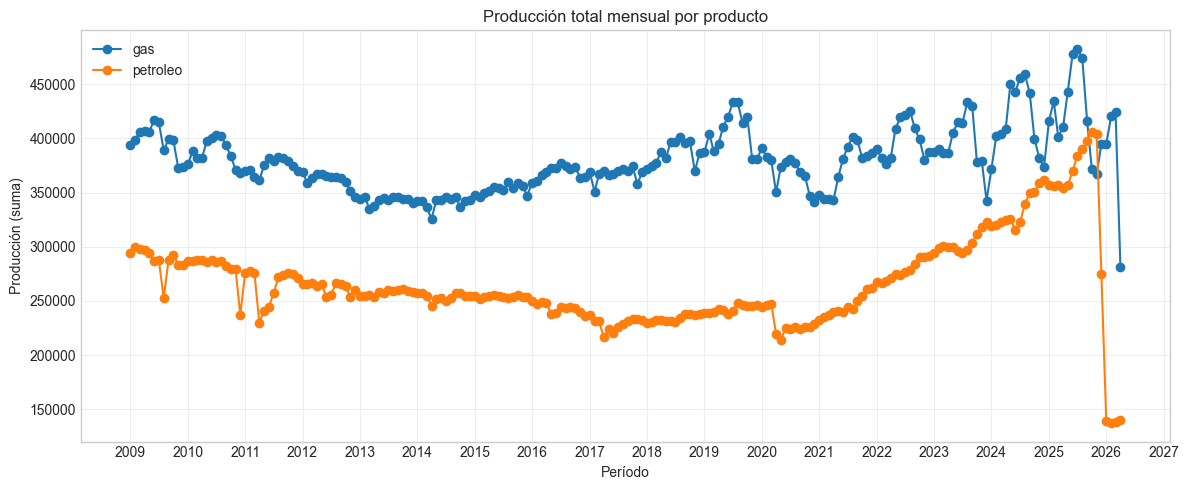

In [7]:
# Gráfica 1: producción total mensual por producto
ts_producto = (
    df_sesco_model.groupby(["periodo_dt", "periodo_str", "producto"], as_index=False)[
        "produccion"
    ]
    .sum()
    .sort_values("periodo_dt")
)

fig, ax = plt.subplots(figsize=(12, 5))
for producto, grp in ts_producto.groupby("producto"):
    ax.plot(grp["periodo_dt"], grp["produccion"], marker="o", label=producto)
ax.set_title("Producción total mensual por producto")
ax.set_xlabel("Período")
ax.set_ylabel("Producción (suma)")
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



--- provincia ---


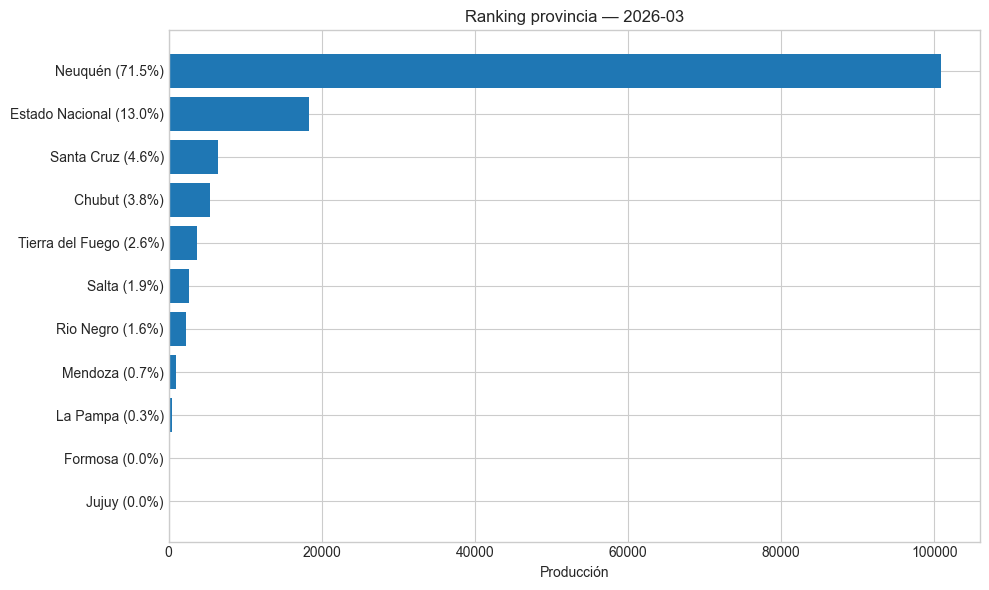


--- cuenca ---


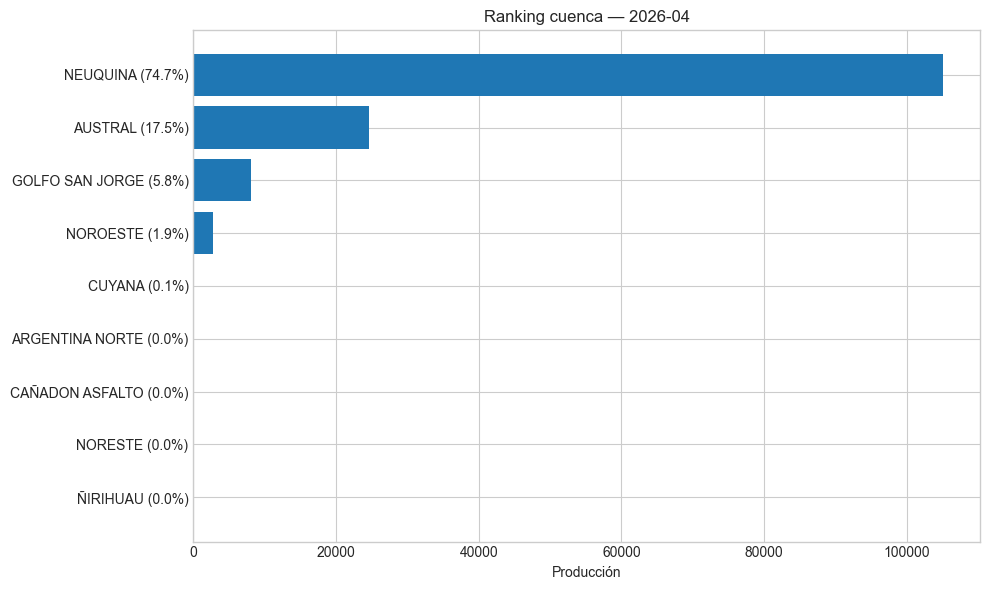


--- empresa ---


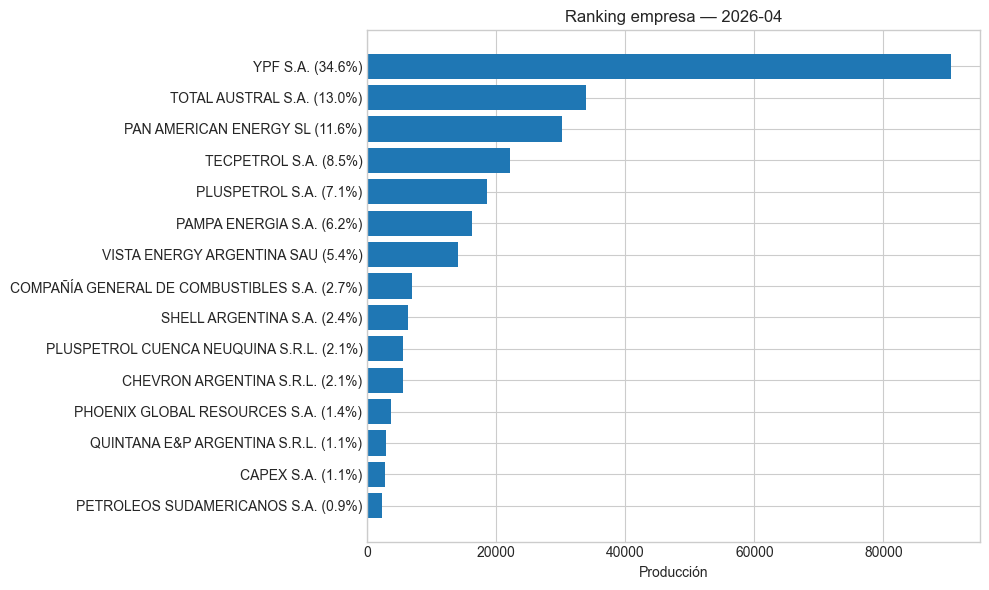

In [8]:
def plot_ranking_ultimo_periodo(df, agrupador_tipo, top_n=15):
    """Ranking en el último período válido del subconjunto."""
    sub = df[df["agrupador_tipo"] == agrupador_tipo].copy()
    if sub.empty:
        print(f"Sin datos para agrupador_tipo={agrupador_tipo}")
        return
    ultimo = sub["periodo_str"].max()
    df_p = sub[sub["periodo_str"] == ultimo]
    ranking = (
        df_p.groupby("agrupador_nombre", as_index=False)["produccion"]
        .sum()
        .sort_values("produccion", ascending=False)
        .head(top_n)
    )
    total = ranking["produccion"].sum()
    ranking["pct"] = ranking["produccion"] / total * 100
    ranking["label"] = ranking.apply(
        lambda r: f"{r['agrupador_nombre']} ({r['pct']:.1f}%)", axis=1
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(ranking["label"], ranking["produccion"])
    ax.invert_yaxis()
    ax.set_title(f"Ranking {agrupador_tipo} — {ultimo}")
    ax.set_xlabel("Producción")
    plt.tight_layout()
    plt.show()
    return ranking


for tipo in ("provincia", "cuenca", "empresa"):
    print(f"\n--- {tipo} ---")
    plot_ranking_ultimo_periodo(df_sesco_model, tipo)


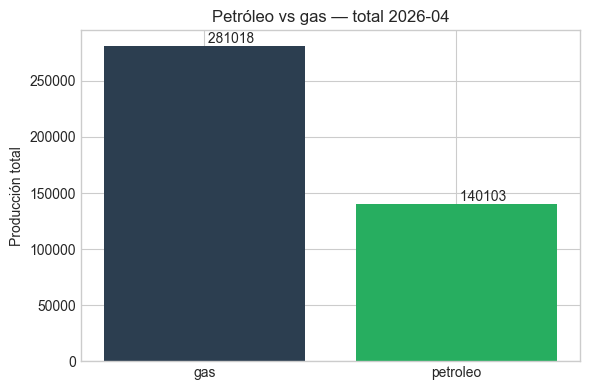

,producto,produccion
0,gas,281017.834467
1,petroleo,140103.430147


In [9]:
# Comparación petróleo vs gas (último período global)
ultimo_global = df_sesco_model["periodo_str"].max()
compare_pg = (
    df_sesco_model[df_sesco_model["periodo_str"] == ultimo_global]
    .groupby("producto", as_index=False)["produccion"]
    .sum()
    .sort_values("produccion", ascending=False)
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(compare_pg["producto"], compare_pg["produccion"], color=["#2c3e50", "#27ae60"])
ax.set_title(f"Petróleo vs gas — total {ultimo_global}")
ax.set_ylabel("Producción total")
for i, row in compare_pg.iterrows():
    ax.text(
        i,
        row["produccion"],
        f" {sp.format_number(row['produccion'], 0)}",
        va="bottom",
    )
plt.tight_layout()
plt.show()
display(compare_pg)


In [ ]:
def plot_top5_evolucion(df, producto, agrupador_tipo="provincia", n_periodos=12):
    """Evolución Top 5 agrupadores en los últimos períodos válidos."""
    sub = df[
        (df["producto"] == producto) & (df["agrupador_tipo"] == agrupador_tipo)
    ].copy()
    if sub.empty:
        print(f"Sin datos: {producto} / {agrupador_tipo}")
        return

    periodos = (
        sub[["periodo_dt", "periodo_str"]]
        .drop_duplicates()
        .sort_values("periodo_dt")["periodo_str"]
        .tail(n_periodos)
        .tolist()
    )
    ultimo = sub["periodo_str"].max()
    top5 = (
        sub[sub["periodo_str"] == ultimo]
        .groupby("agrupador_nombre")["produccion"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .index
    )
    compare = sub[
        sub["periodo_str"].isin(periodos) & sub["agrupador_nombre"].isin(top5)
    ]
    pivot = (
        compare.pivot_table(
            index="periodo_str",
            columns="agrupador_nombre",
            values="produccion",
            aggfunc="sum",
        )
        .reindex(periodos)
    )
    pivot_dt = pd.to_datetime(pivot.index + "-01")

    fig, ax = plt.subplots(figsize=(12, 5))
    for col in pivot.columns:
        ax.plot(pivot_dt, pivot[col], marker="o", linewidth=1.8, label=col)
    ax.set_title(
        f"Top 5 {agrupador_tipo}s — {producto} (últimos {len(periodos)} períodos)"
    )
    ax.set_xlabel("Período")
    ax.set_ylabel("Producción")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    display(pivot.round(2))


plot_top5_evolucion(df_sesco_model, "petroleo")
plot_top5_evolucion(df_sesco_model, "gas")


## 8. Resumen

- Cada recurso exporta `{resource_key}_model_clean.csv` en `data/processed/`.
- El unificado queda en `sesco_produccion_model_clean.csv`.
- Validaciones por recurso en `sesco_validaciones_resumen.csv`.